<a href="https://colab.research.google.com/github/srishti-06069/ITA-/blob/main/Water%20leakage%20Latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

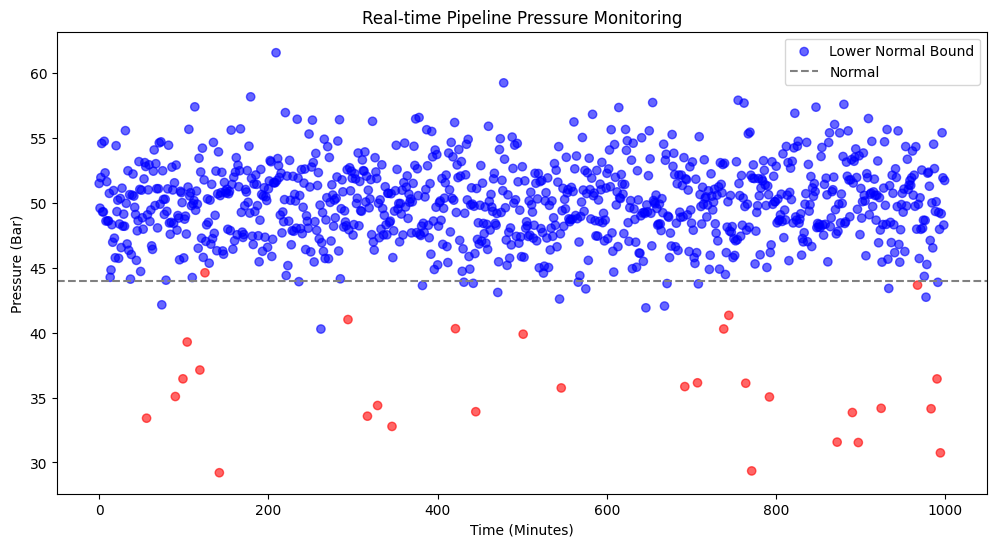

--- Maintenance Alert Log ---
     pressure_bar  flow_rate_Lmin         status
56      33.408692     1361.095521  LEAK DETECTED
90      35.077462     1199.192364  LEAK DETECTED
99      36.439979     1334.922750  LEAK DETECTED
104     39.276680     1378.493297  LEAK DETECTED
119     37.118721     1292.261635  LEAK DETECTED


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. DATA SIMULATION (Based on Report Methodology [cite: 336-343])
np.random.seed(42)
n_samples = 1000

# Normal Operating Conditions [cite: 337-338]
data = {
    'pressure_bar': np.random.normal(50, 3, n_samples),
    'flow_rate_Lmin': np.random.normal(1000, 50, n_samples),
    'vibration_units': np.random.normal(5, 1, n_samples)
}
df = pd.DataFrame(data)

# Injecting Leak Anomalies (approx 3% of data [cite: 340, 348])
# Leaks show: Low Pressure, High Flow, High Vibration [cite: 331]
anomaly_indices = np.random.choice(range(n_samples), size=30, replace=False)
df.loc[anomaly_indices, 'pressure_bar'] -= np.random.uniform(10, 20, 30)
df.loc[anomaly_indices, 'flow_rate_Lmin'] += np.random.uniform(200, 400, 30)
df.loc[anomaly_indices, 'vibration_units'] += np.random.uniform(5, 10, 30)

# 2. PREPROCESSING [cite: 333, 346]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. ANOMALY DETECTION MODEL (Isolation Forest [cite: 313, 348])
# Contamination set to 0.03 (3%) as per report [cite: 348]
model = IsolationForest(contamination=0.03, random_state=42)
df['anomaly_score'] = model.fit_predict(scaled_data)

# Convert -1 (anomaly) and 1 (normal) to readable labels
df['status'] = df['anomaly_score'].apply(lambda x: 'LEAK DETECTED' if x == -1 else 'Normal')

# 4. RESULTS & VISUALIZATION [cite: 362, 363]
plt.figure(figsize=(12, 6))
colors = {1: 'blue', -1: 'red'}
plt.scatter(df.index, df['pressure_bar'], c=df['anomaly_score'].map(colors), alpha=0.6)
plt.axhline(y=44, color='gray', linestyle='--', label='Lower Normal Bound') # [cite: 359]
plt.title('Real-time Pipeline Pressure Monitoring')
plt.xlabel('Time (Minutes)')
plt.ylabel('Pressure (Bar)')
plt.legend(['Lower Normal Bound', 'Normal', 'Anomaly (Leak)'])
plt.show()

# Output the first few detected leaks [cite: 334]
print("--- Maintenance Alert Log ---")
print(df[df['status'] == 'LEAK DETECTED'][['pressure_bar', 'flow_rate_Lmin', 'status']].head())